<a href="https://colab.research.google.com/github/mahidi07/badminton-pose-analysis/blob/main/01_environment_and_pose_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 01 - Environment Setup and Pose Extraction
**Project:** Automated Pose-Based Analysis of Badminton Player Movements Using Deep Learning  
**Student:** Mahidi Ilangarathna (14486346)  
**Supervisor:** A/Prof. Nabin Sharma, UTS  

---

### What this notebook does

1. Checks GPU availability
2. Installs required libraries
3. Mounts Google Drive and creates the project folder structure
4. Scans the full VideoBadminton dataset (all 18 classes) and samples a fixed number of clips per class
5. Runs YOLOv8-Pose on the sample, extracts 17 keypoints per frame, pads or trims each clip to 30 frames
6. Saves keypoint arrays as .npy files
7. Visualises a skeleton overlay on a sample frame to check detection quality
8. Plots per-joint detection confidence across all processed clips

**Dataset location assumed:**
```
My Drive/14486346_Honours/data/raw_clips/
    00_Short_Serve/
    01_Cross_Court_Flight/
    02_Lift/
    ... (18 class folders)
```

Extracted keypoints will be saved to:
```
My Drive/14486346_Honours/data/keypoints/
```

---
## Section 1 - Check GPU and Install Libraries

In [ ]:
import torch

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("No GPU detected. Go to Runtime > Change runtime type and select T4 GPU before continuing.")

GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
!pip install ultralytics opencv-python-headless -q
print("Libraries installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.0 MB/s eta 0:00:00
Libraries installed.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from pathlib import Path
from ultralytics import YOLO

print("All imports OK")
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All imports OK
OpenCV: 4.13.0
NumPy: 2.0.2
PyTorch: 2.10.0+cu128


---
## Section 2 - Mount Google Drive and Set Up Folders

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE         = '/content/drive/MyDrive/14486346_Honours'
RAW_CLIPS_DIR = os.path.join(BASE, 'data/raw_clips')
KEYPOINTS_DIR = os.path.join(BASE, 'data/keypoints')

for folder in ['data/keypoints', 'models', 'outputs', 'logs']:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("Folder structure ready.")
print("Raw clips source :", RAW_CLIPS_DIR)
print("Keypoints output :", KEYPOINTS_DIR)

Folder structure ready.
Raw clips source : /content/drive/MyDrive/14486346_Honours/data/raw_clips
Keypoints output : /content/drive/MyDrive/14486346_Honours/data/keypoints


---
## Section 3 - Scan Dataset and Select Sample

The full dataset has 18 classes and over 7,000 clips. For this initial run we take a fixed number of clips per class so the extraction completes in a reasonable time and gives a representative diagnostic across all action types.

Adjust `CLIPS_PER_CLASS` below. 10 gives 180 clips total and runs in roughly 20 to 30 minutes on a T4 GPU. Increase it once you are happy with the pipeline.

In [ ]:
CLIPS_PER_CLASS = 10   # change this to sample more or fewer clips per class
RANDOM_SEED     = 42   # fixed seed so sampling is reproducible

random.seed(RANDOM_SEED)

# Scan all 18 class folders and build the sample list
all_classes = sorted([
    d for d in os.listdir(RAW_CLIPS_DIR)
    if os.path.isdir(os.path.join(RAW_CLIPS_DIR, d))
])

sampled_clips = []   # list of (class_name, full_clip_path)
class_summary = {}   # class_name -> (total_available, sampled)

for class_name in all_classes:
    class_path = os.path.join(RAW_CLIPS_DIR, class_name)
    all_clips = [f for f in os.listdir(class_path) if f.endswith('.mp4')]
    n_available = len(all_clips)

    n_sample = min(CLIPS_PER_CLASS, n_available)
    chosen = random.sample(all_clips, n_sample)

    for clip_file in chosen:
        sampled_clips.append((class_name, os.path.join(class_path, clip_file)))

    class_summary[class_name] = (n_available, n_sample)

print(f"Sampling {CLIPS_PER_CLASS} clips per class from {len(all_classes)} classes.")
print(f"Total clips to process: {len(sampled_clips)}")
print()
print(f"{'Class':<30} {'Available':>10} {'Sampled':>8}")
print("-" * 50)
for cls, (avail, sampled) in class_summary.items():
    flag = "  (less than requested)" if sampled < CLIPS_PER_CLASS else ""
    print(f"{cls:<30} {avail:>10} {sampled:>8}{flag}")

Sampling 10 clips per class from 18 classes.
Total clips to process: 180

Class                           Available  Sampled
--------------------------------------------------
00_Short Serve                        881       10
01_Cross Court Flight                 167       10
02_Lift                               758       10
03_Tap Smash                          109       10
04_Block                              316       10
05_Drop Shot                          812       10
06_Push Shot                          401       10
07_Transitional Slice                 123       10
08_Cut                                585       10
09_Rush Shot                          113       10
10_Defensive Clear                    109       10
11_Defensive Drive                    111       10
12_Clear                              945       10
13_Long Serve                         991       10
14_Smash                              822       10
15_Flat Shot                          327       10
16_Rear 

---
## Section 4 - Load YOLOv8-Pose

In [ ]:
# yolov8n-pose.pt is the nano model (~6 MB). Fast and sufficient for initial testing.
# Once the pipeline is validated, swap to yolov8m-pose.pt for better keypoint accuracy.

pose_model = YOLO('yolov8n-pose.pt')

print("YOLOv8n-Pose loaded.")
print("Output: 17 keypoints per person in COCO format.")

YOLOv8n-Pose loaded.
Output: 17 keypoints per person in COCO format.


---
## Section 5 - Configuration and Helper Functions

In [ ]:
TARGET_FRAMES  = 30
NUM_KEYPOINTS  = 17
CONF_THRESHOLD = 0.3

SKELETON_EDGES = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

KEYPOINT_NAMES = [
    'nose','left_eye','right_eye','left_ear','right_ear',
    'left_shoulder','right_shoulder','left_elbow','right_elbow',
    'left_wrist','right_wrist','left_hip','right_hip',
    'left_knee','right_knee','left_ankle','right_ankle'
]

print("Config set.")

Config set.


In [ ]:
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return [], 0
    fps = cap.get(cv2.CAP_PROP_FPS)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames, fps


def standardise_frames(frames, target=TARGET_FRAMES):
    n = len(frames)
    if n == target:
        return frames
    elif n < target:
        return frames + [frames[-1]] * (target - n)
    else:
        indices = np.linspace(0, n - 1, target, dtype=int)
        return [frames[i] for i in indices]


def pick_player(result):
    """
    Returns keypoints for the largest detected bounding box in a frame.
    In full-court footage this is typically the foreground player.
    Returns a (17, 3) array of [x, y, confidence], or None if nothing detected.
    """
    if result.keypoints is None or len(result.keypoints.data) == 0:
        return None

    best_idx  = 0
    best_area = 0

    for i, box in enumerate(result.boxes):
        if float(box.conf[0]) < CONF_THRESHOLD:
            continue
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        area = (x2 - x1) * (y2 - y1)
        if area > best_area:
            best_area = area
            best_idx  = i

    if best_area == 0:
        return None

    return result.keypoints.data[best_idx].cpu().numpy()


def extract_keypoints_from_clip(video_path, model):
    """
    Runs the full extraction pipeline on one clip.
    Returns:
        keypoint_array  : numpy array, shape (TARGET_FRAMES, 17, 3)
        n_missing       : frames where no player was detected
        original_len    : original number of frames before standardisation
    """
    frames, _ = extract_frames(video_path)
    if not frames:
        return None, TARGET_FRAMES, 0

    original_len  = len(frames)
    frames        = standardise_frames(frames)
    kp_array      = np.zeros((TARGET_FRAMES, NUM_KEYPOINTS, 3), dtype=np.float32)
    n_missing     = 0

    for t, result in enumerate(model(frames, verbose=False)):
        kps = pick_player(result)
        if kps is not None:
            kp_array[t] = kps
        else:
            n_missing += 1

    return kp_array, n_missing, original_len


print("Helper functions defined.")

Helper functions defined.


---
## Section 6 - Run Pose Extraction on Sample

In [ ]:
# Processes every clip in the sample and saves one .npy file per clip.
# Already-processed clips are skipped so you can safely rerun this cell.
# Output path mirrors the class folder structure:
#   keypoints/00_Short_Serve/clip_name.npy

extraction_log = []
total = len(sampled_clips)

for i, (class_name, clip_path) in enumerate(sampled_clips):
    clip_name = Path(clip_path).stem
    out_dir   = os.path.join(KEYPOINTS_DIR, class_name)
    os.makedirs(out_dir, exist_ok=True)
    out_path  = os.path.join(out_dir, f"{clip_name}.npy")

    if os.path.exists(out_path):
        print(f"[{i+1}/{total}] Skipping (already done): {class_name}/{clip_name}")
        continue

    print(f"[{i+1}/{total}] {class_name}/{clip_name}.mp4 ...", end=' ', flush=True)

    kp_array, n_missing, orig_len = extract_keypoints_from_clip(clip_path, pose_model)

    if kp_array is None:
        print("FAILED")
        extraction_log.append({
            'clip': clip_name, 'class': class_name,
            'status': 'FAILED', 'orig_frames': 0, 'missing_frames': TARGET_FRAMES
        })
        continue

    np.save(out_path, kp_array)

    status = "OK" if n_missing == 0 else f"PARTIAL ({n_missing}/{TARGET_FRAMES} missing)"
    print(f"{status}  |  original: {orig_len}f")

    extraction_log.append({
        'clip': clip_name, 'class': class_name,
        'status': 'OK' if n_missing == 0 else 'PARTIAL',
        'orig_frames': orig_len, 'missing_frames': n_missing
    })

print("\nExtraction complete.")

[1/180] 00_Short Serve/2022-09-07_17-56-47_dataset_set1_029_002511_002542_A_00.mp4 ... OK  |  original: 31f
[2/180] 00_Short Serve/2022-08-30_18-38-37_dataset_set1_056_005859_005884_B_00.mp4 ... OK  |  original: 25f
[3/180] 00_Short Serve/2022-08-30_18-10-55_dataset_set1_111_010276_010301_B_00.mp4 ... OK  |  original: 25f
[4/180] 00_Short Serve/2022-09-07_19-24-02_dataset_set1_003_000480_000514_A_00.mp4 ... OK  |  original: 34f
[5/180] 00_Short Serve/2022-08-31_18-59-49_dataset_set1_015_001320_001343_A_00.mp4 ... OK  |  original: 23f
[6/180] 00_Short Serve/2022-08-31_18-50-39_dataset_set1_015_002323_002347_B_00.mp4 ... OK  |  original: 24f
[7/180] 00_Short Serve/2022-08-31_18-36-59_dataset_set1_085_005993_006016_A_00.mp4 ... OK  |  original: 23f
[8/180] 00_Short Serve/2022-08-30_19-19-43_dataset_set1_067_005761_005783_B_00.mp4 ... OK  |  original: 22f
[9/180] 00_Short Serve/2022-09-07_19-11-05_dataset_set1_113_011120_011162_A_00.mp4 ... OK  |  original: 42f
[10/180] 00_Short Serve/2022

In [ ]:
if extraction_log:
    ok      = sum(1 for s in extraction_log if s['status'] == 'OK')
    partial = sum(1 for s in extraction_log if s['status'] == 'PARTIAL')
    failed  = sum(1 for s in extraction_log if s['status'] == 'FAILED')
    valid   = [s for s in extraction_log if s['status'] != 'FAILED']
    avg_missing = np.mean([s['missing_frames'] for s in valid]) if valid else 0

    print("EXTRACTION SUMMARY")
    print("-" * 40)
    print(f"  Total clips     : {len(extraction_log)}")
    print(f"  Clean           : {ok}")
    print(f"  Partial         : {partial}")
    print(f"  Failed          : {failed}")
    print(f"  Avg missing     : {avg_missing:.1f} / {TARGET_FRAMES} frames")
    print()

    # Per-class partial rate
    print(f"{'Class':<30} {'OK':>4} {'Partial':>8} {'Failed':>7}")
    print("-" * 52)
    for cls in all_classes:
        cls_logs = [s for s in extraction_log if s['class'] == cls]
        c_ok  = sum(1 for s in cls_logs if s['status'] == 'OK')
        c_par = sum(1 for s in cls_logs if s['status'] == 'PARTIAL')
        c_fai = sum(1 for s in cls_logs if s['status'] == 'FAILED')
        if cls_logs:
            print(f"  {cls:<28} {c_ok:>4} {c_par:>8} {c_fai:>7}")

EXTRACTION SUMMARY
----------------------------------------
  Total clips     : 180
  Clean           : 177
  Partial         : 3
  Failed          : 0
  Avg missing     : 0.0 / 30 frames

Class                            OK  Partial  Failed
----------------------------------------------------
  00_Short Serve                 10        0       0
  01_Cross Court Flight           9        1       0
  02_Lift                        10        0       0
  03_Tap Smash                   10        0       0
  04_Block                       10        0       0
  05_Drop Shot                   10        0       0
  06_Push Shot                    9        1       0
  07_Transitional Slice          10        0       0
  08_Cut                         10        0       0
  09_Rush Shot                    9        1       0
  10_Defensive Clear             10        0       0
  11_Defensive Drive             10        0       0
  12_Clear                       10        0       0
  13_Long Serve 

---
## Section 7 - Visual Quality Check

Draws the skeleton overlay on a sample frame. Change `SAMPLE_CLASS` to the name of any folder in raw_clips to inspect that class.

Low confidence joints (below 0.3): [('nose', 0.16), ('left_eye', 0.07), ('right_eye', 0.11)]


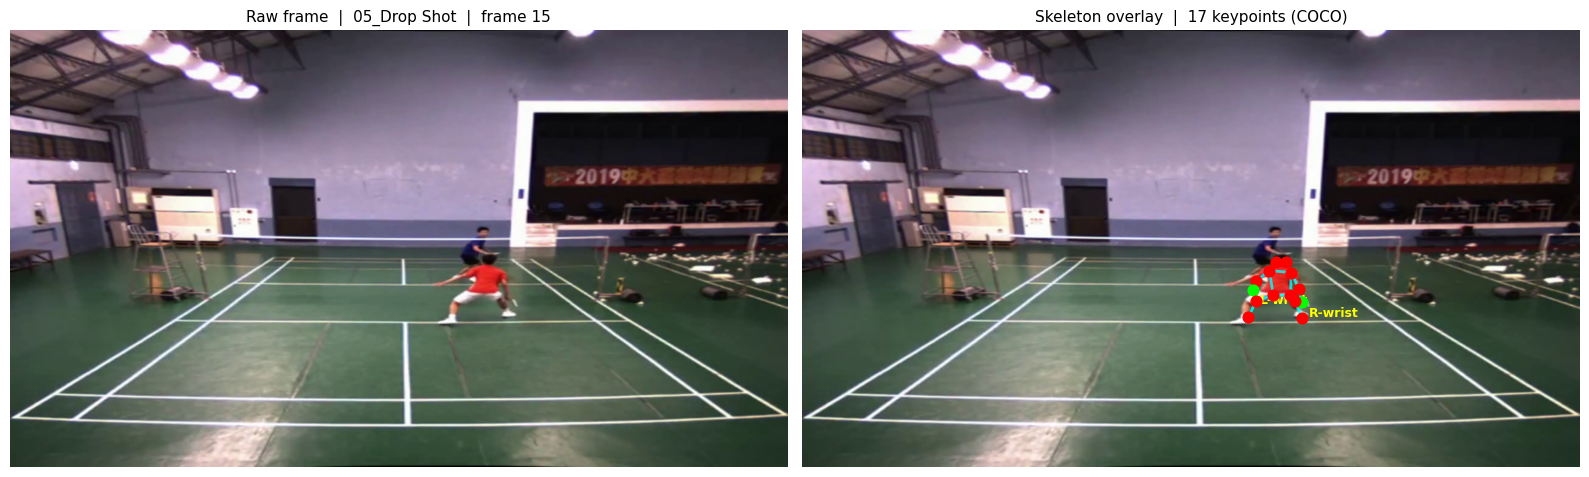

Saved to: /content/drive/MyDrive/14486346_Honours/outputs/sample_skeleton_overlay.png


In [ ]:
SAMPLE_CLASS     = all_classes[5]   # e.g. '00_Short_Serve'. Change to any class name.
SAMPLE_CLIP_IDX  = 0                # which clip within that class (0-indexed)
SAMPLE_FRAME_IDX = 15               # which frame to inspect (0 to 29)

class_clips = [(cls, p) for cls, p in sampled_clips if cls == SAMPLE_CLASS]

if not class_clips:
    print("No sampled clips found for class:", SAMPLE_CLASS)
else:
    _, sample_path = class_clips[SAMPLE_CLIP_IDX]
    sample_frames, _ = extract_frames(sample_path)
    sample_frames = standardise_frames(sample_frames)

    frame     = sample_frames[SAMPLE_FRAME_IDX].copy()
    result    = pose_model(frame, verbose=False)[0]
    kps       = pick_player(result)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].imshow(frame_rgb)
    axes[0].set_title(f'Raw frame  |  {SAMPLE_CLASS}  |  frame {SAMPLE_FRAME_IDX}', fontsize=11)
    axes[0].axis('off')

    axes[1].imshow(frame_rgb)
    axes[1].set_title('Skeleton overlay  |  17 keypoints (COCO)', fontsize=11)
    axes[1].axis('off')

    if kps is not None:
        for (j1, j2) in SKELETON_EDGES:
            x1, y1, c1 = kps[j1]
            x2, y2, c2 = kps[j2]
            if c1 > 0.3 and c2 > 0.3:
                axes[1].plot([x1, x2], [y1, y2], 'cyan', linewidth=2, alpha=0.8)

        for j, (x, y, conf) in enumerate(kps):
            if conf > 0.3:
                color = 'lime' if j in [9, 10] else 'red'
                axes[1].scatter(x, y, c=color, s=60, zorder=5)

        for wrist_idx, label in [(9, 'L-wrist'), (10, 'R-wrist')]:
            x, y, conf = kps[wrist_idx]
            if conf > 0.3:
                axes[1].annotate(label, (x, y), textcoords='offset points',
                                 xytext=(5, -10), color='yellow', fontsize=9, fontweight='bold')

        low_conf = [(KEYPOINT_NAMES[j], round(float(kps[j, 2]), 2))
                    for j in range(17) if kps[j, 2] < 0.3]
        print("Low confidence joints (below 0.3):", low_conf if low_conf else "None")
    else:
        axes[1].text(640, 360, 'NO PLAYER DETECTED', color='red',
                     fontsize=18, ha='center', va='center')
        print("No player detected. Try a different SAMPLE_CLASS or SAMPLE_FRAME_IDX.")

    plt.tight_layout()
    out = os.path.join(BASE, 'outputs/sample_skeleton_overlay.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved to:", out)

---
## Section 8 - Verify Saved Arrays and Confidence Diagnostics

In [ ]:
# Load one saved .npy file and confirm shape and values

npy_files = list(Path(KEYPOINTS_DIR).rglob('*.npy'))

if not npy_files:
    print("No .npy files found. Run Section 6 first.")
else:
    sample_npy = npy_files[0]
    data = np.load(sample_npy)

    print("Sample file    :", sample_npy.name)
    print("Shape          :", data.shape, "  expected:", (TARGET_FRAMES, 17, 3))
    print("Dtype          :", data.dtype)
    print("Value range    :", round(float(data.min()), 3), "to", round(float(data.max()), 3))

    zero_frames = np.all(data == 0, axis=(1, 2))
    print("Zero frames    :", zero_frames.sum(), "/", TARGET_FRAMES)
    print()

    print("Frame 15 keypoints:")
    print(f"  {'Joint':<18} {'x':>6}  {'y':>6}  {'conf':>6}")
    print("  " + "-" * 38)
    for j, name in enumerate(KEYPOINT_NAMES):
        x, y, c = data[15, j]
        note = "  <- wrist" if j in [9, 10] else ""
        print(f"  {name:<18} {x:>6.1f}  {y:>6.1f}  {c:>6.3f}{note}")

Sample file    : 2022-09-07_17-56-47_dataset_set1_029_002511_002542_A_00.npy
Shape          : (30, 17, 3)   expected: (30, 17, 3)
Dtype          : float32
Value range    : 0.024 to 745.024
Zero frames    : 0 / 30

Frame 15 keypoints:
  Joint                   x       y    conf
  --------------------------------------
  nose                688.7   384.3   0.104
  left_eye            689.7   380.4   0.136
  right_eye           691.6   380.2   0.027
  left_ear            692.4   380.9   0.829
  right_ear           710.7   380.3   0.191
  left_shoulder       687.0   395.0   0.983
  right_shoulder      722.1   394.3   0.948
  left_elbow          667.4   406.8   0.967
  right_elbow         735.9   404.9   0.742
  left_wrist          657.1   401.3   0.893  <- wrist
  right_wrist         720.7   397.9   0.583  <- wrist
  left_hip            692.9   442.5   0.993
  right_hip           715.9   442.1   0.987
  left_knee           687.0   473.2   0.985
  right_knee          715.0   473.7   0.965
 

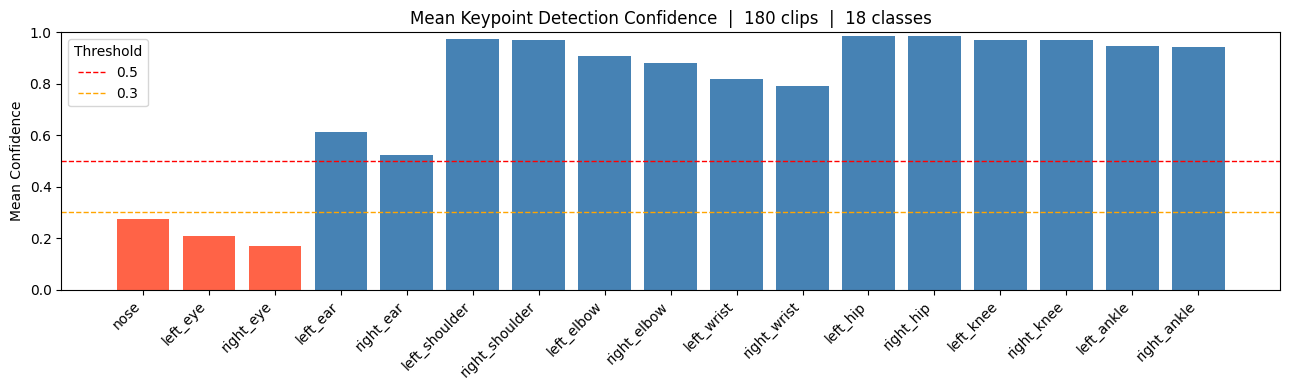

Joints with mean confidence below 0.5:
  nose               0.276
  left_eye           0.21
  right_eye          0.169


In [ ]:
# Bar chart of mean keypoint confidence across all processed clips.
# Joints in red are consistently below 0.5 and may degrade model performance.

if npy_files:
    all_conf = np.stack([np.load(p)[:, :, 2] for p in npy_files])
    mean_conf = all_conf.mean(axis=(0, 1))

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(KEYPOINT_NAMES, mean_conf,
           color=['tomato' if c < 0.5 else 'steelblue' for c in mean_conf])
    ax.axhline(0.5, color='red',    linestyle='--', linewidth=1, label='0.5')
    ax.axhline(0.3, color='orange', linestyle='--', linewidth=1, label='0.3')
    ax.set_ylabel('Mean Confidence')
    ax.set_title(f'Mean Keypoint Detection Confidence  |  {len(npy_files)} clips  |  18 classes')
    ax.set_ylim(0, 1)
    ax.legend(title='Threshold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    out = os.path.join(BASE, 'outputs/keypoint_confidence_chart.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()

    low_joints = [(KEYPOINT_NAMES[j], round(float(mean_conf[j]), 3))
                  for j in range(17) if mean_conf[j] < 0.5]
    if low_joints:
        print("Joints with mean confidence below 0.5:")
        for name, conf in low_joints:
            print(f"  {name:<18} {conf}")
    else:
        print("All joints above 0.5 mean confidence.")

---
## Section 9 - Summary and Next Steps

In [ ]:
npy_count = len(list(Path(KEYPOINTS_DIR).rglob('*.npy')))

print("NOTEBOOK 01 COMPLETE")
print("-" * 40)
print(f"  Classes found    : {len(all_classes)}")
print(f"  Clips sampled    : {len(sampled_clips)}  ({CLIPS_PER_CLASS} per class)")
print(f"  .npy files saved : {npy_count}")
print(f"  Array shape      : ({TARGET_FRAMES}, {NUM_KEYPOINTS}, 3) per clip")
print(f"  Saved to         : {KEYPOINTS_DIR}")
print()
print("Things to note before the next session:")
print("  - Which classes had the most partial or failed detections?")
print("  - Which joints had low mean confidence across all classes?")
print("  - Did the skeleton overlay land on the correct player?")
print("  - Were wrists detected reliably? (critical for shot classification)")
print()
print("Next notebook (02):")
print("  - Build ST-Graph tensors from the saved keypoint arrays")
print("  - Train an LSTM baseline classifier")
print("  - Review per-class accuracy and confusion matrix")

NOTEBOOK 01 COMPLETE
----------------------------------------
  Classes found    : 18
  Clips sampled    : 180  (10 per class)
  .npy files saved : 180
  Array shape      : (30, 17, 3) per clip
  Saved to         : /content/drive/MyDrive/14486346_Honours/data/keypoints

Things to note before the next session:
  - Which classes had the most partial or failed detections?
  - Which joints had low mean confidence across all classes?
  - Did the skeleton overlay land on the correct player?
  - Were wrists detected reliably? (critical for shot classification)

Next notebook (02):
  - Build ST-Graph tensors from the saved keypoint arrays
  - Train an LSTM baseline classifier
  - Review per-class accuracy and confusion matrix
